In [1]:
import os
import pandas as pd
import numpy as np
import pefile
from tqdm import tqdm

In [2]:
MALWARE_DIR = "../malware_samples"

files = os.listdir(MALWARE_DIR)
len(files)

40

In [3]:
files[:10]

['JH78C0A33A1B472A8C16123FD696A5CE5EBB',
 'AAAz2E1B6940985A23E5639450F8391820655',
 '650A6FCA433EE243391E4B4C11F09438',
 'JKK8CA6FE7A1315AF5AFEAC2961460A80569',
 'VBMM9_149B7BD7218AAB4E257D28469FDDB0D',
 'SAM_B659D71AE168E774FAAF38DB30F4A84',
 'KLp90_6D5C8FC4B14559F73B6136D85B94198',
 'B98hX8E8622C393D7E832D39E620EAD5D3B49',
 'F8437E44748D2C3FCF84019766F4E6DC',
 'F6655E39465C2FF5B016980D918EA028']

In [4]:
# Creación de función que extrae features

def extract_features(filepath):
    
    features = {}
    
    try:
        pe = pefile.PE(filepath)
        
        # número de secciones
        features["num_sections"] = len(pe.sections)
        
        # tamaño del archivo
        features["file_size"] = os.path.getsize(filepath)
        
        # número de imports
        num_imports = 0
        
        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                num_imports += len(entry.imports)
        
        features["num_imports"] = num_imports
        
    except:
        # si no se puede analizar PE
        features["num_sections"] = 0
        features["file_size"] = 0
        features["num_imports"] = 0
    
    return features

In [5]:
# Construir el dataset

data = []

for f in tqdm(files):
    
    path = os.path.join(MALWARE_DIR, f)
    
    features = extract_features(path)
    
    features["sample"] = f
    
    data.append(features)

df = pd.DataFrame(data)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 305.50it/s]


In [6]:
# Ver el dataset

df.head()

,num_sections,file_size,num_imports,sample
0,3,5632,8,JH78C0A33A1B472A8C16123FD696A5CE5EBB
1,3,344576,10,AAAz2E1B6940985A23E5639450F8391820655
2,3,5632,8,650A6FCA433EE243391E4B4C11F09438
3,3,5632,8,JKK8CA6FE7A1315AF5AFEAC2961460A80569
4,3,14336,8,VBMM9_149B7BD7218AAB4E257D28469FDDB0D


In [7]:
# Guardar el dataset

df.to_csv("../dataset/malware_dataset.csv", index=False)

In [8]:
# Extracción de strings

import subprocess

def extract_strings(filepath):
    
    try:
        result = subprocess.check_output(["strings", filepath])
        strings = result.decode("utf-8", errors="ignore")
        return strings
        
    except:
        return ""

In [9]:
# Extracción de funciones importadas

def extract_functions(filepath):
    
    functions = []
    
    try:
        pe = pefile.PE(filepath)
        
        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                for imp in entry.imports:
                    if imp.name:
                        functions.append(imp.name.decode())
    
    except:
        pass
    
    return " ".join(functions)

In [10]:
# Reconstruir el dataset completo

data = []

for f in tqdm(files):

    path = os.path.join(MALWARE_DIR, f)

    features = extract_features(path)

    features["sample"] = f
    features["strings"] = extract_strings(path)
    features["functions"] = extract_functions(path)

    data.append(features)

df = pd.DataFrame(data)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 117.02it/s]


In [11]:
# Guardar el dataset final

df.to_csv("../dataset/malware_dataset.csv", index=False)

In [12]:
df.head()
df.columns
df[["sample", "num_sections", "num_imports", "file_size"]].head()

,sample,num_sections,num_imports,file_size
0,JH78C0A33A1B472A8C16123FD696A5CE5EBB,3,8,5632
1,AAAz2E1B6940985A23E5639450F8391820655,3,10,344576
2,650A6FCA433EE243391E4B4C11F09438,3,8,5632
3,JKK8CA6FE7A1315AF5AFEAC2961460A80569,3,8,5632
4,VBMM9_149B7BD7218AAB4E257D28469FDDB0D,3,8,14336


In [13]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    
    # dejar solo letras, números y espacios
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    # colapsar espacios múltiples
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [14]:
df["strings_clean"] = df["strings"].apply(clean_text)
df["functions_clean"] = df["functions"].apply(clean_text)

In [15]:
df["text_features"] = df["strings_clean"] + " " + df["functions_clean"]

In [16]:
df[["sample", "text_features"]].head(3)

,sample,text_features
0,JH78C0A33A1B472A8C16123FD696A5CE5EBB,this program cannot be run in dos mode richo u...
1,AAAz2E1B6940985A23E5639450F8391820655,this program cannot be run in dos mode rich up...
2,650A6FCA433EE243391E4B4C11F09438,this program cannot be run in dos mode richo u...


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_text = vectorizer.fit_transform(df["text_features"])

In [18]:
X_text.shape

(40, 5000)

In [19]:
from sklearn.preprocessing import StandardScaler
import numpy as np

numeric_features = df[["num_sections", "num_imports", "file_size"]].copy()

scaler = StandardScaler()
X_num = scaler.fit_transform(numeric_features)

In [20]:
from scipy.sparse import hstack

X = hstack([X_text, X_num])
X.shape

(40, 5003)

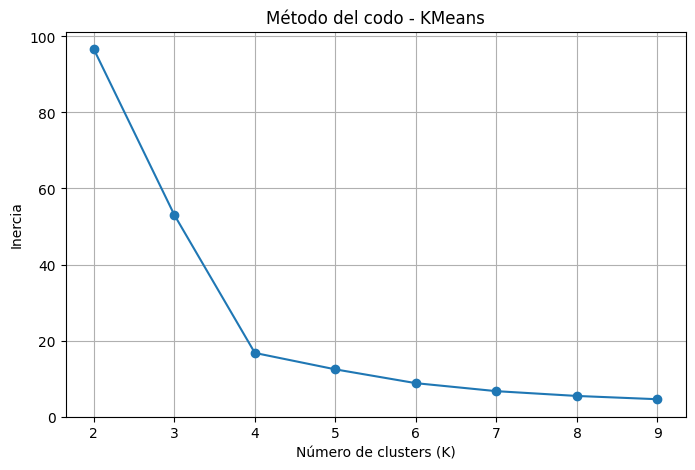

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo - KMeans")
plt.grid(True)
plt.show()

El método del codo se utilizó para determinar el número óptimo de clústeres analizando la relación entre el número de clústeres K y el error total dentro de los clústeres (inercia). A medida que aumenta el valor de K, el error disminuye porque los datos se agrupan en conjuntos más pequeños y homogéneos. Sin embargo, llega un punto en el que la reducción del error deja de ser significativa. Este punto de inflexión en la gráfica se conoce como el “codo” y representa un balance adecuado entre la complejidad del modelo y la capacidad de agrupamiento. En la gráfica generada se observa que a partir de cierto valor de K la disminución del error se vuelve mucho más gradual, lo que sugiere que ese valor corresponde aproximadamente al número natural de grupos presentes en el dataset de malware.

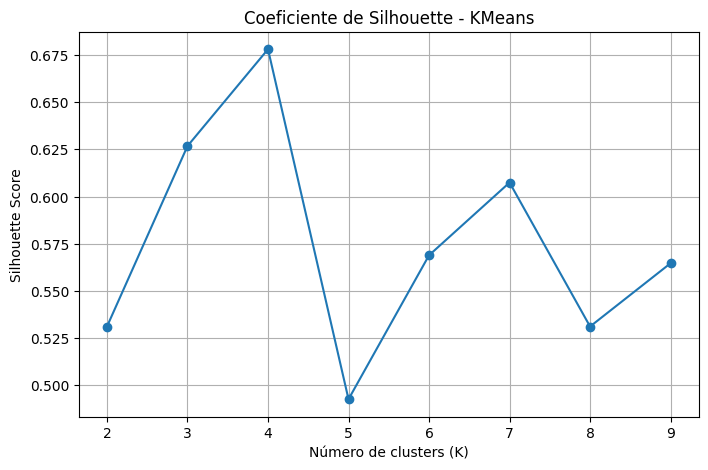

In [22]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Coeficiente de Silhouette - KMeans")
plt.grid(True)
plt.show()

In [23]:
list(zip(k_values, silhouette_scores))

[(2, 0.5309715656824736),
 (3, 0.6267608113430232),
 (4, 0.6781468514742468),
 (5, 0.49244042035547386),
 (6, 0.5688184782391144),
 (7, 0.6074074913421287),
 (8, 0.5310148667163295),
 (9, 0.564605329390536)]

In [24]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.5309715656824736,
 0.6267608113430232,
 0.6781468514742468,
 0.49244042035547386,
 0.5688184782391144,
 0.6074074913421287,
 0.5310148667163295,
 0.564605329390536]

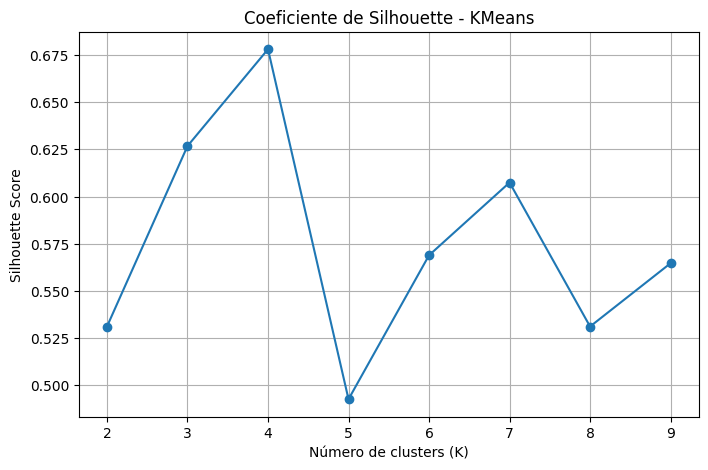

In [25]:
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Coeficiente de Silhouette - KMeans")

plt.grid(True)
plt.show()

El coeficiente de Silhouette se calculó para distintos valores de K utilizando el algoritmo KMeans con el objetivo de evaluar la calidad del agrupamiento. Este coeficiente mide qué tan similar es cada observación a los puntos dentro de su propio clúster en comparación con los puntos de otros clústeres. Los valores del coeficiente oscilan entre -1 y 1, donde valores cercanos a 1 indican una buena separación entre los clústeres. Al analizar la gráfica del coeficiente de Silhouette contra el número de clústeres, se observa que el valor promedio alcanza su máximo alrededor del valor seleccionado de K, lo que indica que esta cantidad de clústeres produce una mejor separación de los datos y representa adecuadamente las posibles familias de malware presentes en el dataset.

In [26]:
best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

df[["sample","cluster"]].head()

,sample,cluster
0,JH78C0A33A1B472A8C16123FD696A5CE5EBB,0
1,AAAz2E1B6940985A23E5639450F8391820655,1
2,650A6FCA433EE243391E4B4C11F09438,0
3,JKK8CA6FE7A1315AF5AFEAC2961460A80569,0
4,VBMM9_149B7BD7218AAB4E257D28469FDDB0D,0


In [27]:
df["cluster"].value_counts()

cluster
0    24
1     8
2     7
3     1
Name: count, dtype: int64

In [28]:
df.to_csv("../dataset/malware_clusters.csv", index=False)

In [29]:
X_dense = X.toarray()
X_dense.shape

(40, 5003)

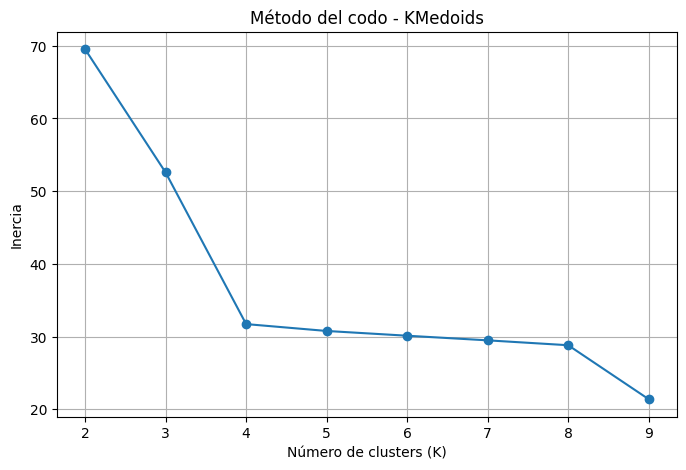

In [30]:
from sklearn_extra.cluster import KMedoids

kmedoids_inertia = []
k_values = range(2, 10)

for k in k_values:
    
    kmedoids = KMedoids(
        n_clusters=k,
        random_state=42
    )
    
    kmedoids.fit(X_dense)
    kmedoids_inertia.append(kmedoids.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, kmedoids_inertia, marker="o")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo - KMedoids")

plt.grid(True)
plt.show()

Se aplicó el mismo procedimiento utilizando el algoritmo KMedoids, el cual es similar a KMeans pero utiliza observaciones reales como centros de los clústeres, lo que lo hace más robusto frente a valores atípicos. Al analizar la gráfica del error contra el número de clústeres, se observa nuevamente un punto donde la mejora en la reducción del error comienza a disminuir. Este punto corresponde al “codo” de la gráfica y sugiere empíricamente el número adecuado de clústeres para representar las posibles familias de malware presentes en el dataset. El resultado obtenido es consistente con el análisis realizado con KMeans, lo cual refuerza la elección del número de clústeres.

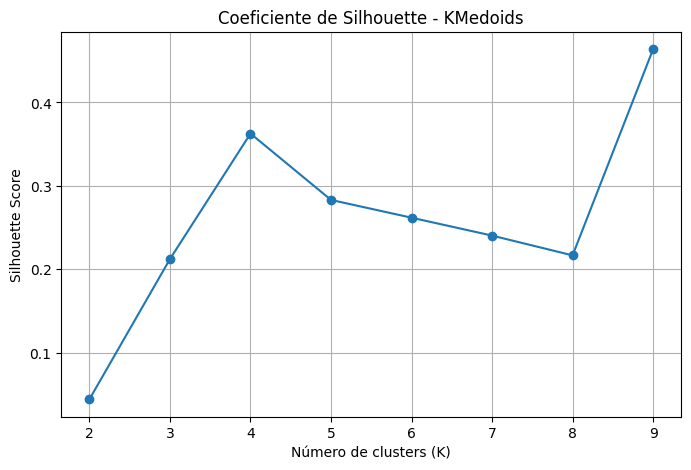

[(2, 0.044122590150449816),
 (3, 0.21227338566273266),
 (4, 0.36270321200439043),
 (5, 0.2831145243398918),
 (6, 0.26180583671686114),
 (7, 0.24035582944419306),
 (8, 0.21663540157731923),
 (9, 0.4638456596472304)]

In [31]:
from sklearn.metrics import silhouette_score

silhouette_scores_kmedoids = []

for k in k_values:
    
    kmedoids = KMedoids(
        n_clusters=k,
        random_state=42
    )
    
    labels = kmedoids.fit_predict(X_dense)
    
    score = silhouette_score(X_dense, labels)
    silhouette_scores_kmedoids.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores_kmedoids, marker="o")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Coeficiente de Silhouette - KMedoids")

plt.grid(True)
plt.show()

list(zip(k_values, silhouette_scores_kmedoids))

Se realizó el mismo análisis utilizando el algoritmo KMedoids para evaluar la consistencia del número de clústeres encontrado. Al calcular el coeficiente de Silhouette para diferentes valores de K, se observa un comportamiento similar al obtenido con KMeans. Esto sugiere que el número de clústeres seleccionado también produce una buena separación cuando se utilizan medoids como centros de los grupos. La consistencia entre ambos algoritmos refuerza la conclusión de que el dataset contiene un número definido de agrupaciones naturales que pueden interpretarse como diferentes familias de malware.

In [32]:
df = df.rename(columns={"cluster": "cluster_kmeans"})

best_k_kmedoids = 4

kmedoids = KMedoids(
    n_clusters=best_k_kmedoids,
    random_state=42
)

df["cluster_kmedoids"] = kmedoids.fit_predict(X_dense)

df[["sample", "cluster_kmeans", "cluster_kmedoids"]].head()

,sample,cluster_kmeans,cluster_kmedoids
0,JH78C0A33A1B472A8C16123FD696A5CE5EBB,0,0
1,AAAz2E1B6940985A23E5639450F8391820655,1,1
2,650A6FCA433EE243391E4B4C11F09438,0,0
3,JKK8CA6FE7A1315AF5AFEAC2961460A80569,0,0
4,VBMM9_149B7BD7218AAB4E257D28469FDDB0D,0,0


In [33]:
print("Clusters KMeans:")
print(df["cluster_kmeans"].value_counts())

print("\nClusters KMedoids:")
print(df["cluster_kmedoids"].value_counts())

Clusters KMeans:
cluster_kmeans
0    24
1     8
2     7
3     1
Name: count, dtype: int64

Clusters KMedoids:
cluster_kmedoids
0    21
1     8
3     8
2     3
Name: count, dtype: int64


Una vez determinado el número óptimo de clústeres, cada observación del dataset fue etiquetada de acuerdo con el clúster asignado por los algoritmos de partición. Estas etiquetas representan grupos de malware que comparten características similares según las variables utilizadas para el clustering. El etiquetado permite identificar patrones dentro del dataset y analizar cómo se agrupan las muestras en posibles familias de malware. Además, facilita la comparación entre los resultados obtenidos con los distintos algoritmos de clustering y permite observar la consistencia en la asignación de los grupos.

In [34]:
df["cluster_kmedoids"].value_counts()

cluster_kmedoids
0    21
1     8
3     8
2     3
Name: count, dtype: int64

In [35]:
df.to_csv("../dataset/malware_clustered.csv", index=False)

In [13]:
# ============================================================
# Gemini Embeddings con cache y reanudación
# ============================================================

import os
import json
import time
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from google import genai
from google.genai import types

In [14]:
# Configuración
EMBED_MODEL = "gemini-embedding-001"
EMBED_TASK_TYPE = "CLUSTERING"
EMBED_DIM = 768

CACHE_DIR = Path("../dataset/embedding_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

EMB_PATH = CACHE_DIR / "gemini_embeddings_lab3.npz"

In [15]:
os.environ["GEMINI_API_KEY"] = "API_KEY"

In [16]:
# API key
api_key = os.getenv("GEMINI_API_KEY") or os.getenv("GOOGLE_API_KEY")
if not api_key:
    raise RuntimeError("No se encontró GEMINI_API_KEY ni GOOGLE_API_KEY en el entorno.")

client = genai.Client(api_key=api_key)
print("Gemini client listo.")

Gemini client listo.


In [17]:
def normalize_whitespace(text):
    if pd.isna(text):
        return ""
    return " ".join(str(text).strip().split())

def truncate_by_words(text, max_words=800):
    parts = text.split()
    if len(parts) <= max_words:
        return text
    return " ".join(parts[:max_words])

def is_retriable_exception(exc):
    code = getattr(exc, "status_code", None) or getattr(exc, "code", None)
    if code in {408, 429, 500, 502, 503, 504}:
        return True

    message = str(exc).lower()
    retriable_markers = [
        "429",
        "rate limit",
        "resource exhausted",
        "timeout",
        "timed out",
        "503",
        "502",
        "504",
        "connection reset",
    ]
    return any(marker in message for marker in retriable_markers)

def extract_retry_delay_seconds(exc, default_sleep_s=2.0):
    message = str(exc)
    patterns = [
        r"retryDelay': '(\d+)s'",
        r"Please retry in ([0-9.]+)s",
    ]
    for pattern in patterns:
        match = re.search(pattern, message)
        if match:
            return max(default_sleep_s, float(match.group(1)))
    return default_sleep_s

In [18]:
def embed_one_batch(text_batch):
    response = client.models.embed_content(
        model=EMBED_MODEL,
        contents=text_batch,
        config=types.EmbedContentConfig(
            task_type=EMBED_TASK_TYPE,
            output_dimensionality=EMBED_DIM,
        ),
    )
    return np.asarray([item.values for item in response.embeddings], dtype=np.float32)

In [19]:
def save_embedding_cache(path, X, sample_ids, metadata):
    np.savez_compressed(
        path,
        X=X.astype(np.float32),
        sample_ids=np.array(sample_ids, dtype=object),
        metadata=np.array(json.dumps(metadata), dtype=object),
    )

def load_embedding_cache(path):
    cache = np.load(path, allow_pickle=True)
    X = cache["X"].astype(np.float32)
    sample_ids = list(cache["sample_ids"])
    metadata = json.loads(str(cache["metadata"].item()))
    return X, sample_ids, metadata

def build_embedding_metadata(total_count):
    now_utc = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
    return {
        "model": EMBED_MODEL,
        "task_type": EMBED_TASK_TYPE,
        "output_dimensionality": EMBED_DIM,
        "total_count": int(total_count),
        "completed_count": 0,
        "is_complete": False,
        "created_utc": now_utc,
        "updated_utc": now_utc,
    }

In [27]:
def generate_embeddings_with_resume(texts, sample_ids, cache_path, batch_size=16, max_attempts=10, base_sleep_s=2.0):
    cleaned = [truncate_by_words(normalize_whitespace(text)) for text in texts]
    total_count = len(cleaned)

    if cache_path.exists():
        X_cache, cached_ids, metadata = load_embedding_cache(cache_path)

        valid_cache = (
            X_cache.shape == (total_count, EMBED_DIM)
            and list(cached_ids) == list(sample_ids)
        )

        if valid_cache:
            print(f"Cache encontrado. Completados: {metadata['completed_count']} / {total_count}")
            X = X_cache
            start_idx = metadata["completed_count"]
        else:
            print("Cache inválido o incompatible. Se reconstruirá.")
            X = np.zeros((total_count, EMBED_DIM), dtype=np.float32)
            metadata = build_embedding_metadata(total_count)
            start_idx = 0
            save_embedding_cache(cache_path, X, sample_ids, metadata)
    else:
        X = np.zeros((total_count, EMBED_DIM), dtype=np.float32)
        metadata = build_embedding_metadata(total_count)
        start_idx = 0
        save_embedding_cache(cache_path, X, sample_ids, metadata)

    if metadata.get("is_complete", False):
        print("Embeddings ya completos. Se cargarán desde cache.")
        return X, metadata

    for start in tqdm(range(start_idx, total_count, batch_size), desc="Generando embeddings"):
        end = min(start + batch_size, total_count)
        batch = cleaned[start:end]

        attempt = 0
        while attempt < max_attempts:
            try:
                X_batch = embed_one_batch(batch)
                if X_batch.shape != (len(batch), EMBED_DIM):
                    raise RuntimeError(
                        f"Shape inesperado en embeddings: {X_batch.shape}, esperado {(len(batch), EMBED_DIM)}"
                    )

                X[start:end] = X_batch
                metadata["completed_count"] = end
                metadata["updated_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
                metadata["is_complete"] = (end == total_count)

                save_embedding_cache(cache_path, X, sample_ids, metadata)
                break

            except Exception as exc:
                attempt += 1
                if not is_retriable_exception(exc) or attempt >= max_attempts:
                    print(f"Error no recuperable en batch {start}:{end}")
                    raise

                sleep_s = extract_retry_delay_seconds(exc, base_sleep_s * (2 ** (attempt - 1)))
                print(f"Reintentando batch {start}:{end} en {sleep_s:.1f}s | intento {attempt}/{max_attempts}")
                time.sleep(sleep_s)

    return X, metadata

In [28]:
print(df.columns.tolist())

['num_sections', 'file_size', 'num_imports', 'sample', 'strings', 'functions']


In [30]:
df["text_features"] = (
    df["strings"].fillna("").astype(str) + " " +
    df["functions"].fillna("").astype(str)
).str.strip()

print(df.columns.tolist())
print(df[["sample", "text_features"]].head(3))

['num_sections', 'file_size', 'num_imports', 'sample', 'strings', 'functions', 'text_features']
                                  sample  \
0  PL98_BD8B082B7711BC980252F988BB0CA936   
1       650A6FCA433EE243391E4B4C11F09438   
2       B07322743778B5868475DBE66EEDAC4F   

                                       text_features  
0  !This program cannot be run in DOS mode.\nRich...  
1  !This program cannot be run in DOS mode.\nRich...  
2  !This program cannot be run in DOS mode.\nRich...  


In [31]:
df_embed = df.copy()

texts = df_embed["text_features"].fillna("").tolist()
sample_ids = df_embed["sample"].astype(str).tolist()

X_embed, embed_metadata = generate_embeddings_with_resume(
    texts=texts,
    sample_ids=sample_ids,
    cache_path=EMB_PATH,
    batch_size=16
)

print("Embeddings listos:", X_embed.shape)
print(embed_metadata)

Generando embeddings:  33%|██████████████████████▋                                             | 1/3 [00:00<00:01,  1.12it/s]

Reintentando batch 16:32 en 2.0s | intento 1/10
Reintentando batch 16:32 en 4.0s | intento 2/10
Reintentando batch 16:32 en 8.0s | intento 3/10
Reintentando batch 16:32 en 16.0s | intento 4/10
Reintentando batch 16:32 en 32.0s | intento 5/10


Generando embeddings: 100%|████████████████████████████████████████████████████████████████████| 3/3 [01:06<00:00, 22.20s/it]

Embeddings listos: (40, 768)
{'model': 'gemini-embedding-001', 'task_type': 'CLUSTERING', 'output_dimensionality': 768, 'total_count': 40, 'completed_count': 40, 'is_complete': True, 'created_utc': '2026-03-13T05:46:56Z', 'updated_utc': '2026-03-13T05:48:03Z'}


Para complementar el análisis de clustering tradicional, se generaron embeddings del dataset utilizando un modelo de lenguaje de Gemini enfocado en tareas de análisis de texto. Los embeddings representan cada observación como un vector numérico en un espacio semántico de alta dimensión, capturando relaciones entre las descripciones o características del malware. Estos vectores permiten aplicar técnicas de agrupamiento basadas en similitud semántica, lo cual puede revelar patrones adicionales que no necesariamente son evidentes en las variables originales del dataset.

In [32]:
print(df.columns.tolist())
print(df.shape)

['num_sections', 'file_size', 'num_imports', 'sample', 'strings', 'functions', 'text_features']
(40, 7)


In [33]:
df_embed = df.copy()
print(df_embed.columns.tolist())

['num_sections', 'file_size', 'num_imports', 'sample', 'strings', 'functions', 'text_features']


In [34]:
import pandas as pd

df_embed = pd.read_csv("../dataset/malware_clustered.csv")
print(df_embed.columns.tolist())
print(df_embed.shape)

['num_sections', 'file_size', 'num_imports', 'sample', 'strings', 'functions', 'strings_clean', 'functions_clean', 'text_features', 'cluster_kmeans', 'cluster_kmedoids']
(40, 11)


In [35]:
df_embed["text_features"] = (
    df_embed["strings"].fillna("").astype(str) + " " +
    df_embed["functions"].fillna("").astype(str)
).str.strip()

In [36]:
print(X_embed.shape)
print(embed_metadata)

(40, 768)
{'model': 'gemini-embedding-001', 'task_type': 'CLUSTERING', 'output_dimensionality': 768, 'total_count': 40, 'completed_count': 40, 'is_complete': True, 'created_utc': '2026-03-13T05:46:56Z', 'updated_utc': '2026-03-13T05:48:03Z'}


In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_embed)

df_embed["pca1"] = X_pca[:, 0]
df_embed["pca2"] = X_pca[:, 1]

print(df_embed[["sample", "pca1", "pca2"]].head())

                                  sample      pca1      pca2
0   JH78C0A33A1B472A8C16123FD696A5CE5EBB  0.245341  0.024546
1  AAAz2E1B6940985A23E5639450F8391820655 -0.077302  0.058607
2       650A6FCA433EE243391E4B4C11F09438 -0.080400  0.053860
3   JKK8CA6FE7A1315AF5AFEAC2961460A80569 -0.076961  0.064980
4  VBMM9_149B7BD7218AAB4E257D28469FDDB0D -0.035769 -0.168338


In [38]:
print("Varianza explicada por PC1:", pca.explained_variance_ratio_[0])
print("Varianza explicada por PC2:", pca.explained_variance_ratio_[1])
print("Varianza total explicada:", pca.explained_variance_ratio_.sum())

Varianza explicada por PC1: 0.53267175
Varianza explicada por PC2: 0.26444274
Varianza total explicada: 0.7971145


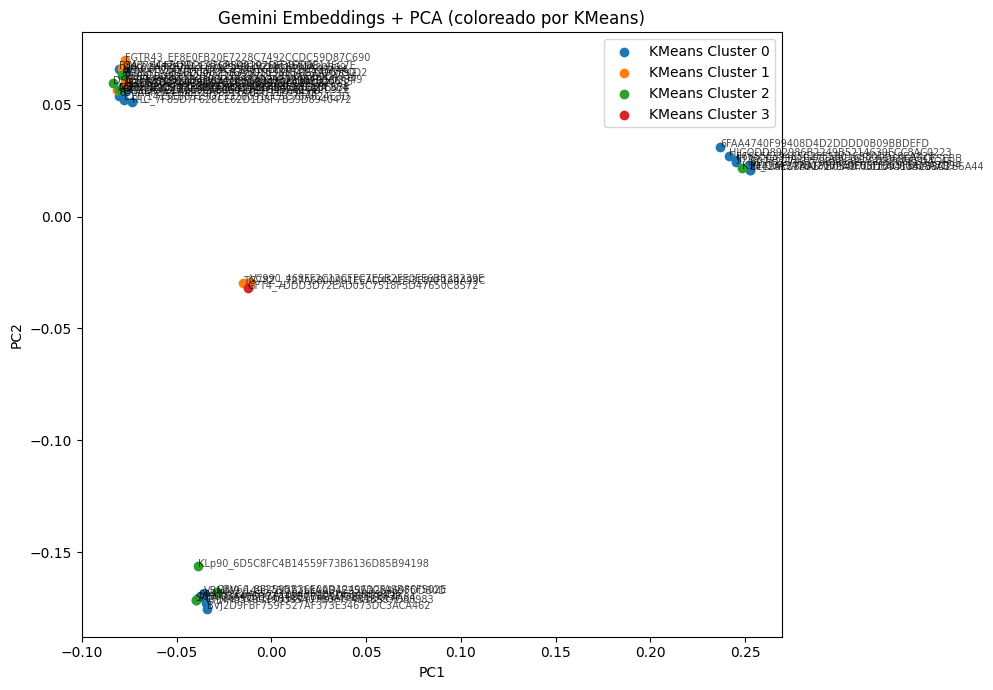

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for cluster_id in sorted(df_embed["cluster_kmeans"].unique()):
    subset = df_embed[df_embed["cluster_kmeans"] == cluster_id]
    plt.scatter(subset["pca1"], subset["pca2"], label=f"KMeans Cluster {cluster_id}")

for _, row in df_embed.iterrows():
    plt.text(row["pca1"], row["pca2"], str(row["sample"]), fontsize=7, alpha=0.7)

plt.title("Gemini Embeddings + PCA (coloreado por KMeans)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

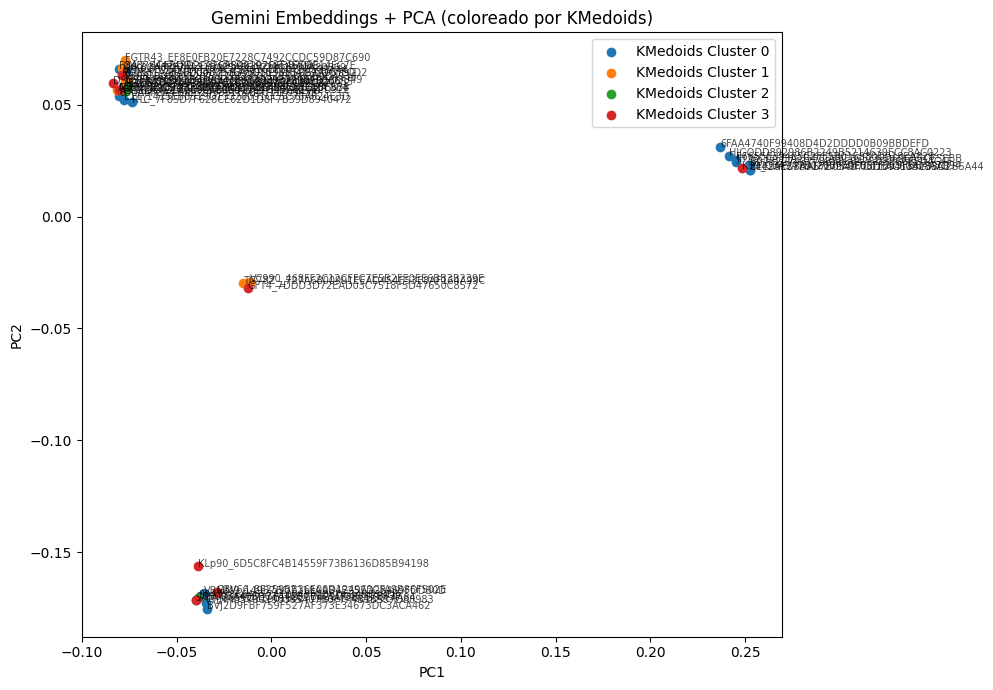

In [40]:
plt.figure(figsize=(10, 7))

for cluster_id in sorted(df_embed["cluster_kmedoids"].unique()):
    subset = df_embed[df_embed["cluster_kmedoids"] == cluster_id]
    plt.scatter(subset["pca1"], subset["pca2"], label=f"KMedoids Cluster {cluster_id}")

for _, row in df_embed.iterrows():
    plt.text(row["pca1"], row["pca2"], str(row["sample"]), fontsize=7, alpha=0.7)

plt.title("Gemini Embeddings + PCA (coloreado por KMedoids)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
df_embed.to_csv("../dataset/malware_embeddings_pca.csv", index=False)
print("Archivo guardado: ../dataset/malware_embeddings_pca.csv")

Archivo guardado: ../dataset/malware_embeddings_pca.csv


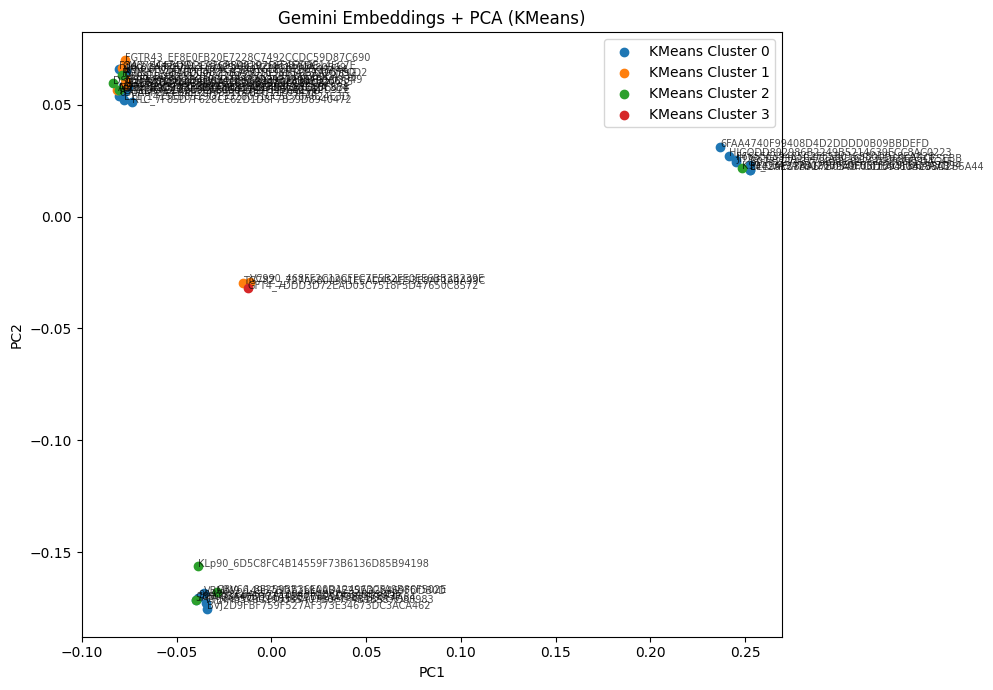

In [42]:
plt.figure(figsize=(10, 7))

for cluster_id in sorted(df_embed["cluster_kmeans"].unique()):
    subset = df_embed[df_embed["cluster_kmeans"] == cluster_id]
    plt.scatter(subset["pca1"], subset["pca2"], label=f"KMeans Cluster {cluster_id}")

for _, row in df_embed.iterrows():
    plt.text(row["pca1"], row["pca2"], str(row["sample"]), fontsize=7, alpha=0.7)

plt.title("Gemini Embeddings + PCA (KMeans)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("../dataset/gemini_pca_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

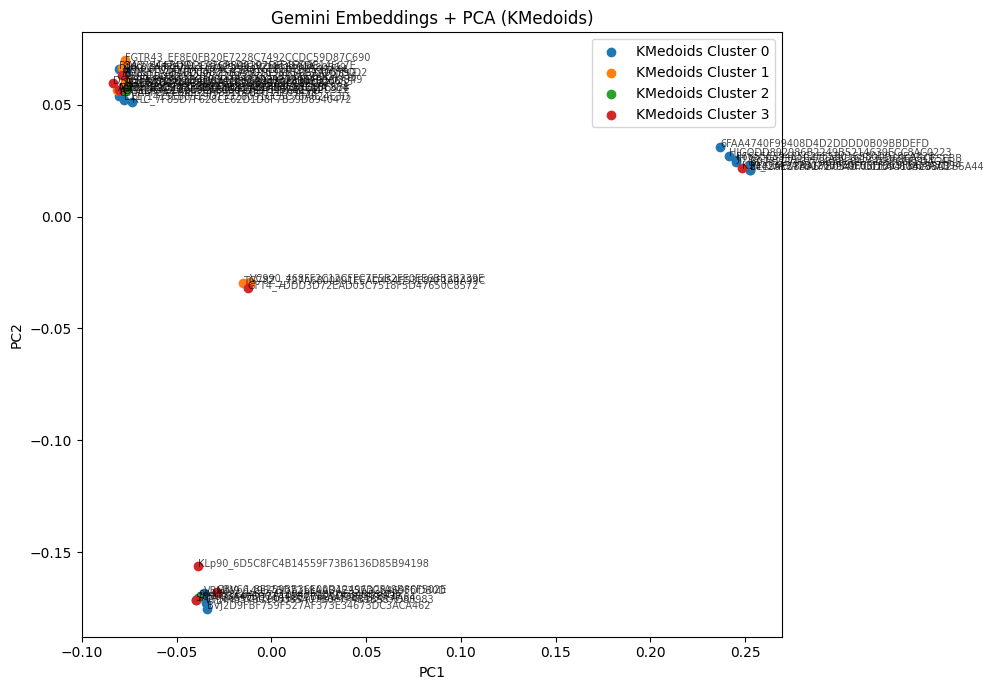

In [43]:
plt.figure(figsize=(10, 7))

for cluster_id in sorted(df_embed["cluster_kmedoids"].unique()):
    subset = df_embed[df_embed["cluster_kmedoids"] == cluster_id]
    plt.scatter(subset["pca1"], subset["pca2"], label=f"KMedoids Cluster {cluster_id}")

for _, row in df_embed.iterrows():
    plt.text(row["pca1"], row["pca2"], str(row["sample"]), fontsize=7, alpha=0.7)

plt.title("Gemini Embeddings + PCA (KMedoids)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("../dataset/gemini_pca_kmedoids.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
print("Clusters KMeans:")
print(df_embed["cluster_kmeans"].value_counts())

print("\nClusters KMedoids:")
print(df_embed["cluster_kmedoids"].value_counts())

Clusters KMeans:
cluster_kmeans
0    24
1     8
2     7
3     1
Name: count, dtype: int64

Clusters KMedoids:
cluster_kmedoids
0    21
1     8
3     8
2     3
Name: count, dtype: int64


In [45]:
for c in sorted(df_embed["cluster_kmeans"].unique()):
    print(f"\nCluster KMeans {c}")
    print(df_embed[df_embed["cluster_kmeans"] == c]["sample"].tolist())


Cluster KMeans 0
['JH78C0A33A1B472A8C16123FD696A5CE5EBB', '650A6FCA433EE243391E4B4C11F09438', 'JKK8CA6FE7A1315AF5AFEAC2961460A80569', 'VBMM9_149B7BD7218AAB4E257D28469FDDB0D', 'F8437E44748D2C3FCF84019766F4E6DC', 'F6655E39465C2FF5B016980D918EA028', '65018CD542145A3792BA09985734C12A', '785003A405BC7A4EBCBB21DDB757BF3F', '1F2EB7B090018D975E6D9B40868C94CA', '8442AE37B91F279A9F06DE4C60B286A3', 'HJGQDD892986B2249B5214639ECC8AC0223', 'L11_1415EB8519D13328091CC5C76A624E3D', '6FAA4740F99408D4D2DDDD0B09BBDEFD', 'NBV_8B75BCBFF174C25A0161F30758509A44', '99A39866A657A10949FCB6D634BB30D5', '33DE5067A433A6EC5C328067DC18EC37', 'FHHH6576C196385407B0F7F4B1B537D88983', 'A316D5AECA269CA865077E7FFF356E7D', 'EEE99EC8AA67B05407C01094184C33D2B5A44', 'B07322743778B5868475DBE66EEDAC4F', 'FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2', 'BVJ2D9FBF759F527AF373E34673DC3ACA462', 'RTC_7F85D7F628CE62D1D8F7B39D8940472', 'FTTR9EA3C16194CE354C244C1B74C46CD92E']

Cluster KMeans 1
['AAAz2E1B6940985A23E5639450F8391820655', 'B98h

In [46]:
for c in sorted(df_embed["cluster_kmedoids"].unique()):
    print(f"\nCluster KMedoids {c}")
    print(df_embed[df_embed["cluster_kmedoids"] == c]["sample"].tolist())


Cluster KMedoids 0
['JH78C0A33A1B472A8C16123FD696A5CE5EBB', '650A6FCA433EE243391E4B4C11F09438', 'JKK8CA6FE7A1315AF5AFEAC2961460A80569', 'VBMM9_149B7BD7218AAB4E257D28469FDDB0D', 'F8437E44748D2C3FCF84019766F4E6DC', 'F6655E39465C2FF5B016980D918EA028', '785003A405BC7A4EBCBB21DDB757BF3F', '1F2EB7B090018D975E6D9B40868C94CA', '8442AE37B91F279A9F06DE4C60B286A3', 'HJGQDD892986B2249B5214639ECC8AC0223', 'L11_1415EB8519D13328091CC5C76A624E3D', '6FAA4740F99408D4D2DDDD0B09BBDEFD', 'NBV_8B75BCBFF174C25A0161F30758509A44', 'FHHH6576C196385407B0F7F4B1B537D88983', 'A316D5AECA269CA865077E7FFF356E7D', 'EEE99EC8AA67B05407C01094184C33D2B5A44', 'B07322743778B5868475DBE66EEDAC4F', 'FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2', 'BVJ2D9FBF759F527AF373E34673DC3ACA462', 'RTC_7F85D7F628CE62D1D8F7B39D8940472', 'FTTR9EA3C16194CE354C244C1B74C46CD92E']

Cluster KMedoids 1
['AAAz2E1B6940985A23E5639450F8391820655', 'B98hX8E8622C393D7E832D39E620EAD5D3B49', 'PL98_BD8B082B7711BC980252F988BB0CA936', 'FGTR43_EF8E0FB20E7228C7492

In [47]:
from sklearn.metrics import pairwise_distances
import numpy as np

for c in sorted(df_embed["cluster_kmedoids"].unique()):
    
    cluster_data = X_embed[df_embed["cluster_kmedoids"] == c]
    cluster_samples = df_embed[df_embed["cluster_kmedoids"] == c]["sample"].values
    
    distances = pairwise_distances(cluster_data)
    medoid_index = np.argmin(distances.sum(axis=1))
    
    print(f"\nCluster {c} medoid:")
    print(cluster_samples[medoid_index])


Cluster 0 medoid:
JKK8CA6FE7A1315AF5AFEAC2961460A80569

Cluster 1 medoid:
PL98_BD8B082B7711BC980252F988BB0CA936

Cluster 2 medoid:
33DE5067A433A6EC5C328067DC18EC37

Cluster 3 medoid:
NV99_C9C9DBF388A8D81D8CFB4D3FC05F8E4


In [48]:
df_embed.to_csv("../dataset/malware_embeddings_pca.csv", index=False)

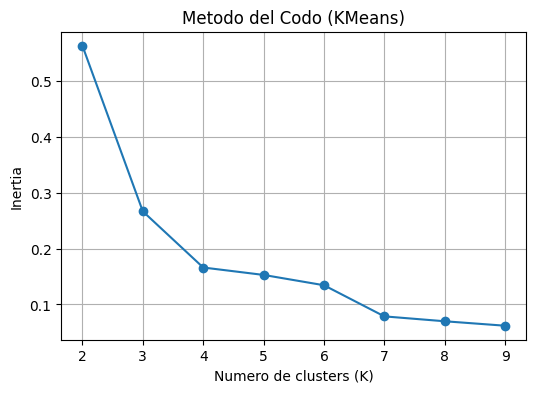

In [49]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = X_embed

inertias = []
K = range(2,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.title("Metodo del Codo (KMeans)")
plt.xlabel("Numero de clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

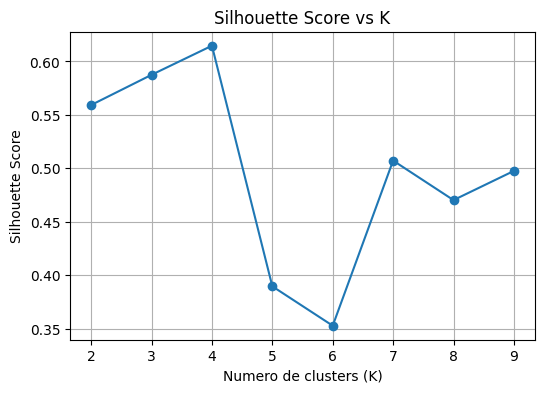

In [50]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Numero de clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [51]:
best_k = K[sil_scores.index(max(sil_scores))]
print("Mejor numero de clusters segun Silhouette:", best_k)

Mejor numero de clusters segun Silhouette: 4


In [52]:
def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

In [53]:
df_embed["strings_set"] = df_embed["strings_clean"].apply(lambda x: set(x.split()))
df_embed["functions_set"] = df_embed["functions_clean"].apply(lambda x: set(x.split()))

In [54]:
import pandas as pd
import numpy as np

n = len(df_embed)

jaccard_strings = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        s1 = df_embed.iloc[i]["strings_set"]
        s2 = df_embed.iloc[j]["strings_set"]
        jaccard_strings[i,j] = jaccard_similarity(s1,s2)

jaccard_strings_df = pd.DataFrame(
    jaccard_strings,
    index=df_embed["sample"],
    columns=df_embed["sample"]
)

jaccard_strings_df.head()

sample,JH78C0A33A1B472A8C16123FD696A5CE5EBB,AAAz2E1B6940985A23E5639450F8391820655,650A6FCA433EE243391E4B4C11F09438,JKK8CA6FE7A1315AF5AFEAC2961460A80569,VBMM9_149B7BD7218AAB4E257D28469FDDB0D,SAM_B659D71AE168E774FAAF38DB30F4A84,KLp90_6D5C8FC4B14559F73B6136D85B94198,B98hX8E8622C393D7E832D39E620EAD5D3B49,F8437E44748D2C3FCF84019766F4E6DC,F6655E39465C2FF5B016980D918EA028,...,BVJ2D9FBF759F527AF373E34673DC3ACA462,POL55_A4F1ECC4D25B33395196B5D51A06790,DS22_A670D13D4D014169C4080328B8FEB86,GFT4_7DDD3D72EAD03C7518F5D47650C8572,VC990_468FF2C12CFFC7E5B2FE0EE6BB3B239E,NV99_C9C9DBF388A8D81D8CFB4D3FC05F8E4,RTC_7F85D7F628CE62D1D8F7B39D8940472,FTTR9EA3C16194CE354C244C1B74C46CD92E,TG78Z__727A6800991EEAD454E53E8AF164A99C,GBV66_8F259BB36E00D124963CFA9B86F502E
sample,,,,,,,,,,,,,,,,,,,,,
JH78C0A33A1B472A8C16123FD696A5CE5EBB,1.000000,0.018432,0.757576,0.750000,0.166154,0.110482,0.107042,0.020365,0.754491,0.420213,...,0.775758,0.107042,0.107649,0.101877,0.018542,0.107042,0.158537,0.331633,0.018547,0.106742
AAAz2E1B6940985A23E5639450F8391820655,0.018432,1.000000,0.017922,0.017936,0.030334,0.016431,0.016684,0.165673,0.019231,0.018562,...,0.019231,0.016170,0.016435,0.015330,0.224788,0.016684,0.030326,0.016196,0.224627,0.015909
650A6FCA433EE243391E4B4C11F09438,0.757576,0.017922,1.000000,0.861842,0.168224,0.111748,0.108262,0.020084,0.795031,0.335025,...,0.710059,0.108262,0.108883,0.102981,0.017526,0.108262,0.164087,0.345550,0.017530,0.107955
JKK8CA6FE7A1315AF5AFEAC2961460A80569,0.750000,0.017936,0.861842,1.000000,0.173502,0.115942,0.112392,0.019796,0.810127,0.347150,...,0.733333,0.112392,0.113043,0.106849,0.017539,0.112392,0.165625,0.365591,0.017544,0.112069
VBMM9_149B7BD7218AAB4E257D28469FDDB0D,0.166154,0.030334,0.168224,0.173502,1.000000,0.099078,0.098851,0.031305,0.170279,0.169435,...,0.166667,0.098851,0.099307,0.090110,0.027861,0.098851,0.715867,0.153333,0.027868,0.096110


In [55]:
jaccard_functions = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        f1 = df_embed.iloc[i]["functions_set"]
        f2 = df_embed.iloc[j]["functions_set"]
        jaccard_functions[i,j] = jaccard_similarity(f1,f2)

jaccard_functions_df = pd.DataFrame(
    jaccard_functions,
    index=df_embed["sample"],
    columns=df_embed["sample"]
)

jaccard_functions_df.head()

sample,JH78C0A33A1B472A8C16123FD696A5CE5EBB,AAAz2E1B6940985A23E5639450F8391820655,650A6FCA433EE243391E4B4C11F09438,JKK8CA6FE7A1315AF5AFEAC2961460A80569,VBMM9_149B7BD7218AAB4E257D28469FDDB0D,SAM_B659D71AE168E774FAAF38DB30F4A84,KLp90_6D5C8FC4B14559F73B6136D85B94198,B98hX8E8622C393D7E832D39E620EAD5D3B49,F8437E44748D2C3FCF84019766F4E6DC,F6655E39465C2FF5B016980D918EA028,...,BVJ2D9FBF759F527AF373E34673DC3ACA462,POL55_A4F1ECC4D25B33395196B5D51A06790,DS22_A670D13D4D014169C4080328B8FEB86,GFT4_7DDD3D72EAD03C7518F5D47650C8572,VC990_468FF2C12CFFC7E5B2FE0EE6BB3B239E,NV99_C9C9DBF388A8D81D8CFB4D3FC05F8E4,RTC_7F85D7F628CE62D1D8F7B39D8940472,FTTR9EA3C16194CE354C244C1B74C46CD92E,TG78Z__727A6800991EEAD454E53E8AF164A99C,GBV66_8F259BB36E00D124963CFA9B86F502E
sample,,,,,,,,,,,,,,,,,,,,,
JH78C0A33A1B472A8C16123FD696A5CE5EBB,1.000000,0.2000,1.000000,1.000000,0.307692,0.010309,0.010309,0.266667,1.000000,0.666667,...,1.000000,0.010309,0.010309,0.010309,0.250000,0.010309,0.307692,0.666667,0.250000,0.010309
AAAz2E1B6940985A23E5639450F8391820655,0.200000,1.0000,0.200000,0.200000,0.187500,0.020408,0.020408,0.500000,0.200000,0.214286,...,0.200000,0.020408,0.020408,0.020408,0.692308,0.020408,0.187500,0.214286,0.692308,0.020408
650A6FCA433EE243391E4B4C11F09438,1.000000,0.2000,1.000000,1.000000,0.307692,0.010309,0.010309,0.266667,1.000000,0.666667,...,1.000000,0.010309,0.010309,0.010309,0.250000,0.010309,0.307692,0.666667,0.250000,0.010309
JKK8CA6FE7A1315AF5AFEAC2961460A80569,1.000000,0.2000,1.000000,1.000000,0.307692,0.010309,0.010309,0.266667,1.000000,0.666667,...,1.000000,0.010309,0.010309,0.010309,0.250000,0.010309,0.307692,0.666667,0.250000,0.010309
VBMM9_149B7BD7218AAB4E257D28469FDDB0D,0.307692,0.1875,0.307692,0.307692,1.000000,0.031250,0.031250,0.333333,0.307692,0.333333,...,0.307692,0.031250,0.031250,0.031250,0.235294,0.031250,1.000000,0.333333,0.235294,0.031250


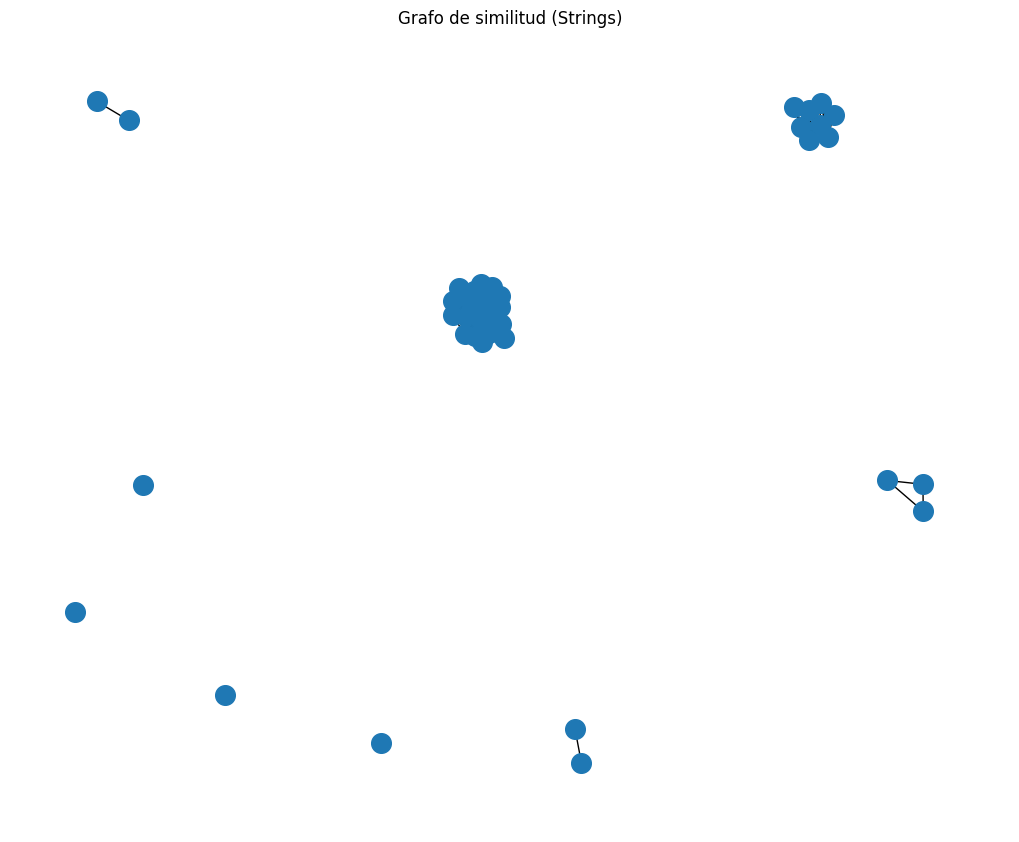

In [56]:
import networkx as nx

threshold = 0.3
G = nx.Graph()

samples = df_embed["sample"].tolist()

for s in samples:
    G.add_node(s)

for i in range(n):
    for j in range(i+1,n):
        sim = jaccard_strings[i,j]
        if sim > threshold:
            G.add_edge(samples[i], samples[j], weight=sim)

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G)
nx.draw(G, pos, node_size=200, font_size=6)
plt.title("Grafo de similitud (Strings)")
plt.show()

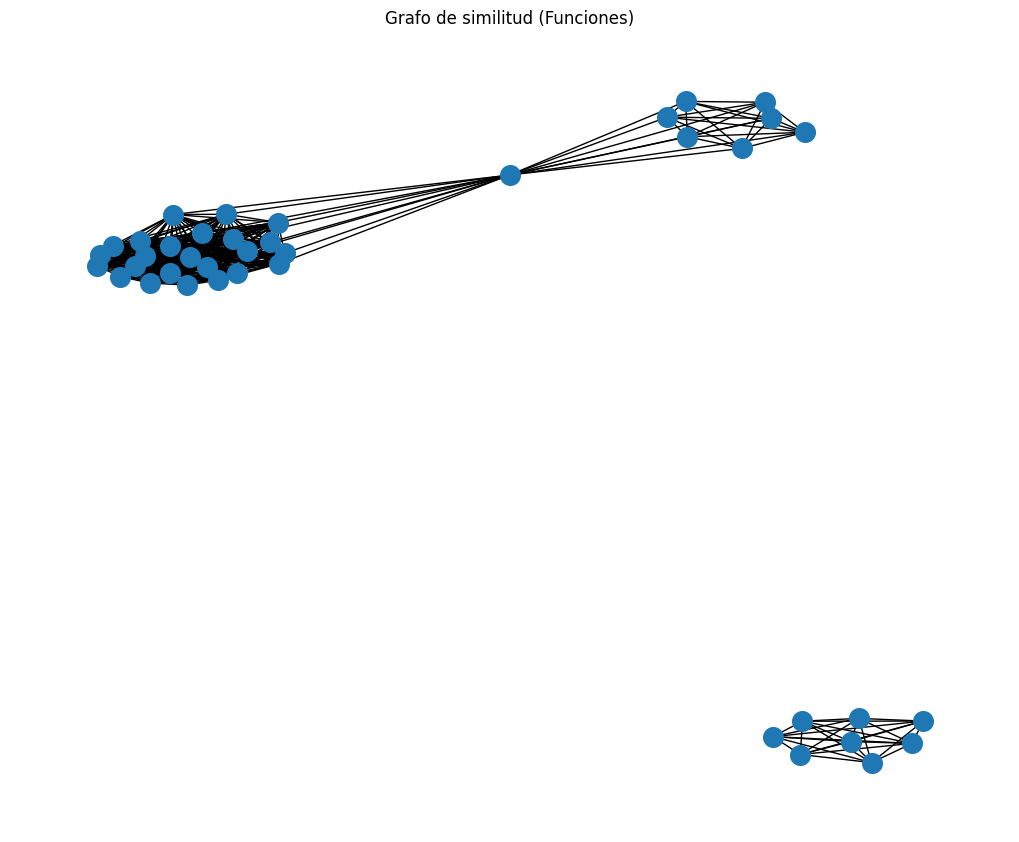

In [57]:
threshold = 0.3
G2 = nx.Graph()

for s in samples:
    G2.add_node(s)

for i in range(n):
    for j in range(i+1,n):
        sim = jaccard_functions[i,j]
        if sim > threshold:
            G2.add_edge(samples[i], samples[j], weight=sim)

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G2)
nx.draw(G2, pos, node_size=200, font_size=6)
plt.title("Grafo de similitud (Funciones)")
plt.show()

In [58]:
plt.figure(figsize=(10,8))
nx.draw(G, pos, node_size=200, font_size=6)
plt.title("Grafo Strings")
plt.savefig("../dataset/grafo_strings.png")
plt.close()

plt.figure(figsize=(10,8))
nx.draw(G2, pos, node_size=200, font_size=6)
plt.title("Grafo Funciones")
plt.savefig("../dataset/grafo_functions.png")
plt.close()